## Import data


In [12]:
import polars as pl

pdb_v = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_validation_triad.conf_af3.parquet"
)
cresta = pl.read_parquet("../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet")
cresta_win = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad_w.conf_af3.parquet"
).filter(pl.col("peptide") == pl.col("suspected_9mer"))

# iedb_I_1x_neg_conf = pl.read_parquet(
#     "../../data/iedb_I_1x_neg/triad/staged/iedb_I_1x_neg_triad.conf.parquet"
# )
# iedb_II_1x_neg_conf = pl.read_parquet(
#     "../../data/iedb_II_1x_neg/triad/staged/iedb_II_1x_neg_triad.conf.parquet"
# )

## Utility functions


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import wilcoxon


def plot_histogram(
    arr, bins=10, xlabel="Peptide length", ylabel="Frequency", title="Histogram"
):
    plt.hist(arr, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


def get_contact_ndarr(df):
    contact_maps_cognate = np.array(
        df.filter(pl.col("cognate")).select("contact_map").to_series().to_list()
    )

    contact_maps_noncognate = np.array(
        df.filter(~pl.col("cognate")).select("contact_map").to_series().to_list()
    )

    return contact_maps_cognate, contact_maps_noncognate


def collapse_contact_maps(contact_maps, mhc_class):
    if mhc_class == "II":
        exp_pos = [1, 2, 4, 6, 7]
        non_exp_pos = [0, 3, 5, 8]

    else:
        exp_pos = [3, 4, 5, 6, 7]
        non_exp_pos = [0, 1, 2, 8]

    exp_arr = contact_maps[:, :, exp_pos].sum(axis=1).mean(axis=1)
    non_exp_arr = contact_maps[:, :, non_exp_pos].sum(axis=1).mean(axis=1)

    return exp_arr, non_exp_arr


def wilcoxon_exp_vs_nonexp(fold_change, mhc_class):
    if mhc_class == "II":
        exp_pos = [1, 2, 4, 6, 7]
        non_exp_pos = [0, 3, 5, 8]

    else:
        exp_pos = [3, 4, 5, 6, 7]
        non_exp_pos = [0, 1, 2, 8]

    stat, pvalue = wilcoxon(fold_change, alternative="greater")

    print(
        f"Median logfold change in mean number of TCR contacts between expected TCR-facing\n"
        f"({exp_pos}) and expected MHC-facing ({non_exp_pos}) positions:\n\t{np.median(fold_change)} "
        f"\n p value:\n\t{pvalue}"
    )

    return stat, pvalue


def plot_heatmap(
    contact_maps_cognate, contact_maps_noncognate, mhc_class, suptitle=None
):

    cmap_gray_blue = LinearSegmentedColormap.from_list(
        "WhiteToBlue", ["white", "darkblue"]
    )

    mean_cognate = np.mean(contact_maps_cognate, axis=0)
    mean_noncognate = np.mean(contact_maps_noncognate, axis=0)

    col_labels = [str(i) for i in range(1, 10)] + ["HLA A", "HLA B"]

    row_segments = []
    for chain in ["Alpha", "Beta"]:
        for seg in [
            "fwr_1",
            "cdr_1",
            "fwr_2",
            "cdr_2",
            "fwr_3",
            "cdr_3",
            "fwr_4",
        ]:
            row_segments.append(f"{' '.join(seg.split('_')).upper()}")

    fig, axs = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

    vmin = min(mean_cognate.min(), mean_noncognate.min())
    vmax = max(mean_cognate.max(), mean_noncognate.max())

    t = []
    p = []
    log = []

    if mhc_class == "II":
        exp_pos = [1, 2, 4, 6, 7]
        non_exp_pos = [0, 3, 5, 8]

    else:
        exp_pos = [3, 4, 5, 6, 7]
        non_exp_pos = [0, 1, 2, 8]

    for ax, data, title, full_data in zip(
        axs,
        [mean_cognate, mean_noncognate],
        ["Cognate", "Noncognate"],
        [contact_maps_cognate, contact_maps_noncognate],
    ):
        im = ax.imshow(data, aspect="auto", cmap=cmap_gray_blue, vmin=vmin, vmax=vmax)
        ax.set_title(title + f" (n={full_data.shape[0]})", pad=20)
        ax.set_xticks(np.arange(len(col_labels)))
        ax.set_xticklabels(col_labels)
        ax.set_yticks(np.arange(len(row_segments)))
        ax.set_yticklabels(row_segments)

        # ax.set_xticks(range(mean_cognate.shape[1]), labels=col_labels,
        #               ha="right", rotation_mode="anchor")
        # ax.set_yticks(range(mean_cognate.shape[0]), labels=row_segments)

        ax.spines[:].set_visible(False)

        ax.grid(which="minor", color="w", linestyle="-", linewidth=3)
        ax.tick_params(which="minor", bottom=False, left=False)

        # ax.tick_params(axis='both', length=0)

        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks([3, 10])
        ax2.set_yticklabels(["alpha", "beta"])
        ax2.spines["left"].set_position(("outward", 60))
        ax2.spines["left"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.yaxis.set_ticks_position("left")
        ax2.yaxis.set_label_position("left")
        ax2.tick_params(axis="y", length=0)

    cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.02)
    cbar.set_label("Mean num contacts", rotation=-90, va="bottom")

    if suptitle:
        fig.suptitle(suptitle, fontsize="large", y=1.03)

    return fig

## PDB Triads, class II


### Length distribution


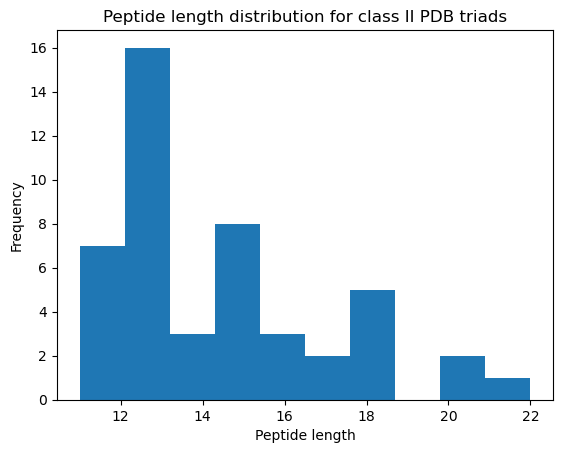

In [35]:
from tcrtrifold.viz_utils import heatmap
import matplotlib.pyplot as plt


len_dist = pdb_af3_conf.filter(pl.col("mhc_class") == "II", pl.col("cognate")).select(
    pl.col("peptide").str.len_chars()
)

plot_histogram(len_dist, title="Peptide length distribution for class II PDB triads")

### Heatmap


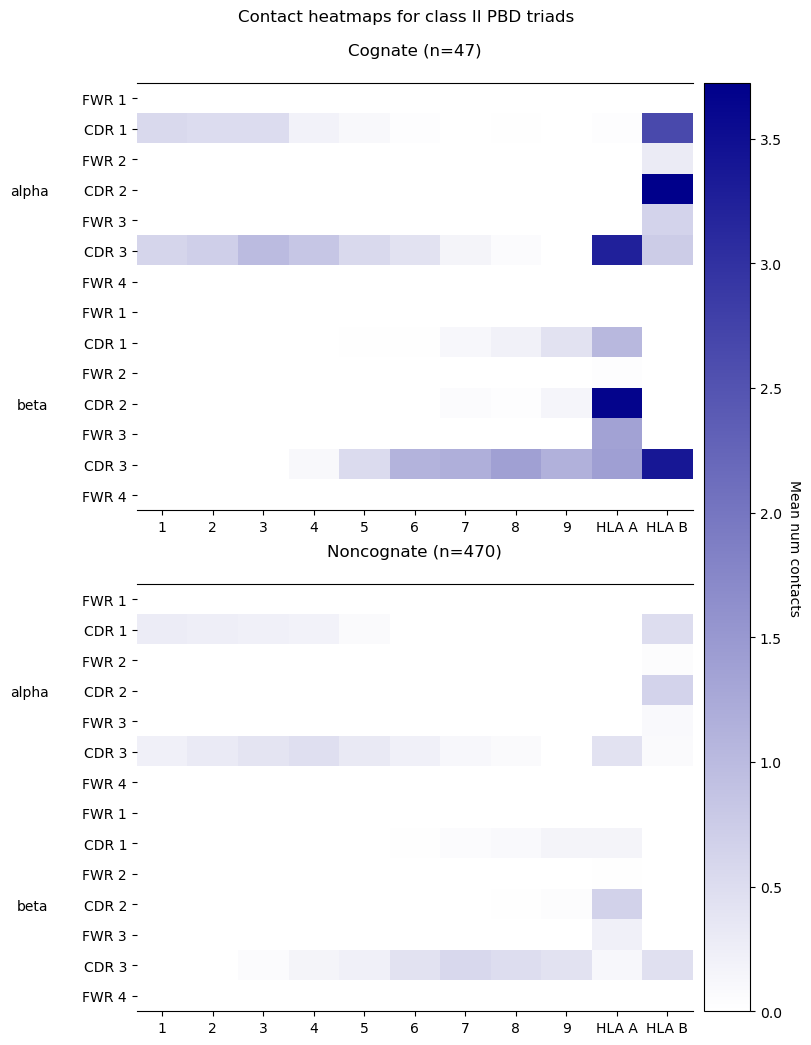

In [36]:
contact_cog, contact_noncog = get_contact_ndarr(
    pdb_af3_conf.filter(
        pl.col("peptide").str.len_chars() >= 9, pl.col("mhc_class") == "II"
    )
)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "II",
    suptitle="Contact heatmaps for class II PBD triads",
)

In [37]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "II")

fold_change = np.log2((cog_exp + 1e-2) / (cog_nonexp + 1e-2))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "II")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([1, 2, 4, 6, 7]) and expected MHC-facing ([0, 3, 5, 8]) positions:
	0.0 
 p value:
	0.29568502571562794


## PDB Triads, class I


### Length distribution


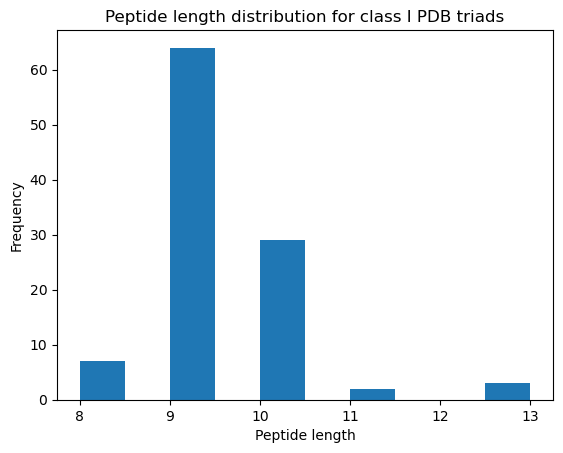

In [ ]:
from tcrtrifold.viz_utils import heatmap
import matplotlib.pyplot as plt


len_dist = pdb_af3_conf.filter(pl.col("mhc_class") == "I", pl.col("cognate")).select(
    pl.col("peptide").str.len_chars()
)

plot_histogram(len_dist, title="Peptide length distribution for class I PDB triads")

### Heatmap


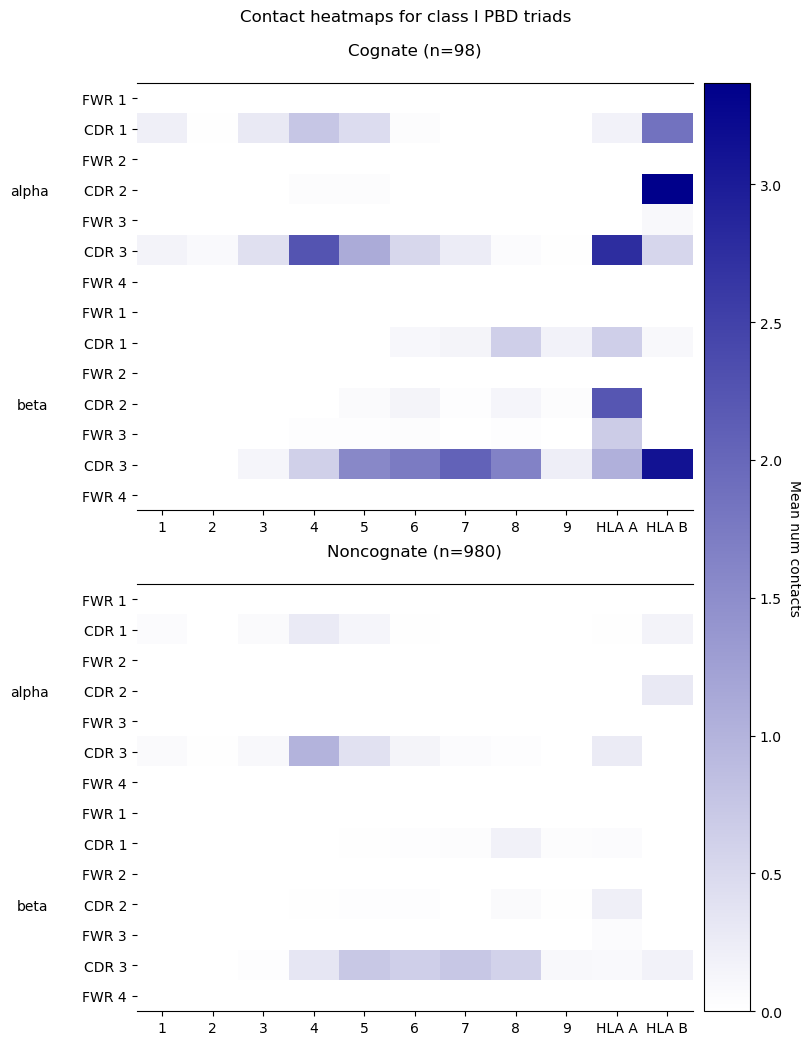

In [39]:
contact_cog, contact_noncog = get_contact_ndarr(
    pdb_af3_conf.filter(
        pl.col("peptide").str.len_chars() >= 9, pl.col("mhc_class") == "I"
    )
)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "I",
    suptitle="Contact heatmaps for class I PBD triads",
)

In [40]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "I")

fold_change = np.log2((cog_exp + 1) / (cog_nonexp + 1))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "I")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([3, 4, 5, 6, 7]) and expected MHC-facing ([0, 1, 2, 8]) positions:
	1.4854268271702418 
 p value:
	1.3331585278394143e-17


## Cresta triads


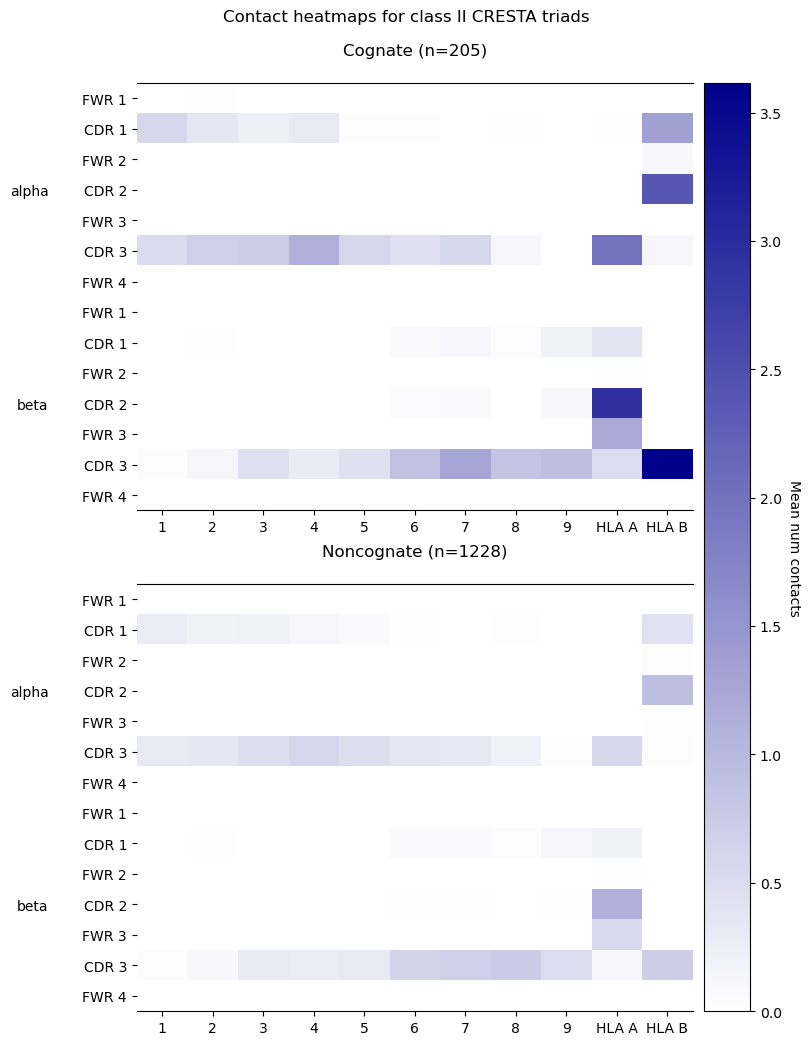

In [3]:
contact_cog, contact_noncog = get_contact_ndarr(cresta)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "II",
    suptitle="Contact heatmaps for class II CRESTA triads",
)

In [4]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "II")

fold_change = np.log2((cog_exp + 1) / (cog_nonexp + 1))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "II")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([1, 2, 4, 6, 7]) and expected MHC-facing ([0, 3, 5, 8]) positions:
	-0.03242147769237734 
 p value:
	0.4502059340553191


/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TypeError: Invalid shape () for image data

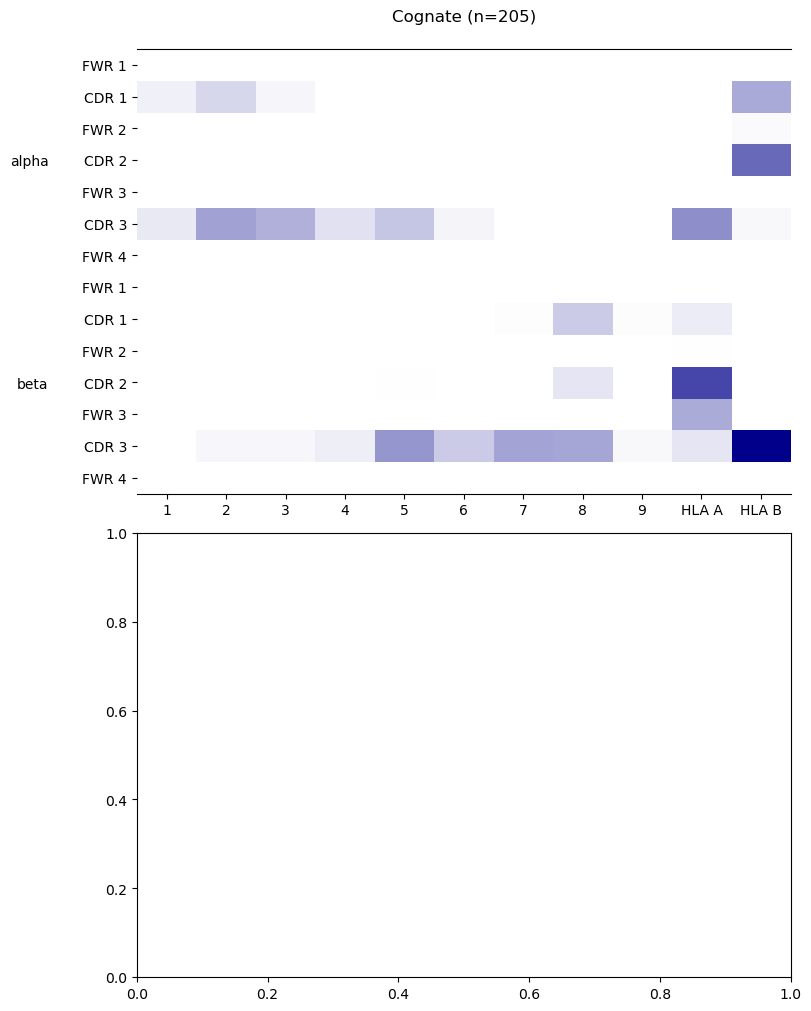

In [13]:
contact_cog, contact_noncog = get_contact_ndarr(cresta_win)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "II",
    suptitle="Contact heatmaps for class II CRESTA triads (windowed)",
)

In [10]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "II")

fold_change = np.log2((cog_exp + 1) / (cog_nonexp + 1))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "II")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([1, 2, 4, 6, 7]) and expected MHC-facing ([0, 3, 5, 8]) positions:
	0.056583528366367514 
 p value:
	3.787706090694681e-50


## IEDB class II triads


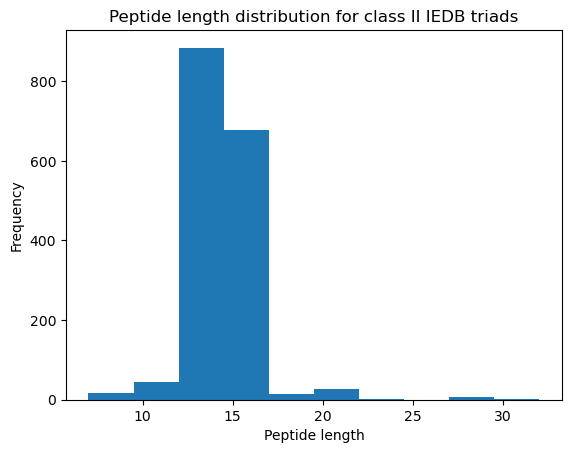

In [43]:
len_dist = iedb_II_1x_neg_conf.filter(
    pl.col("mhc_class") == "II", pl.col("cognate")
).select(pl.col("peptide").str.len_chars())

plot_histogram(len_dist, title="Peptide length distribution for class II IEDB triads")

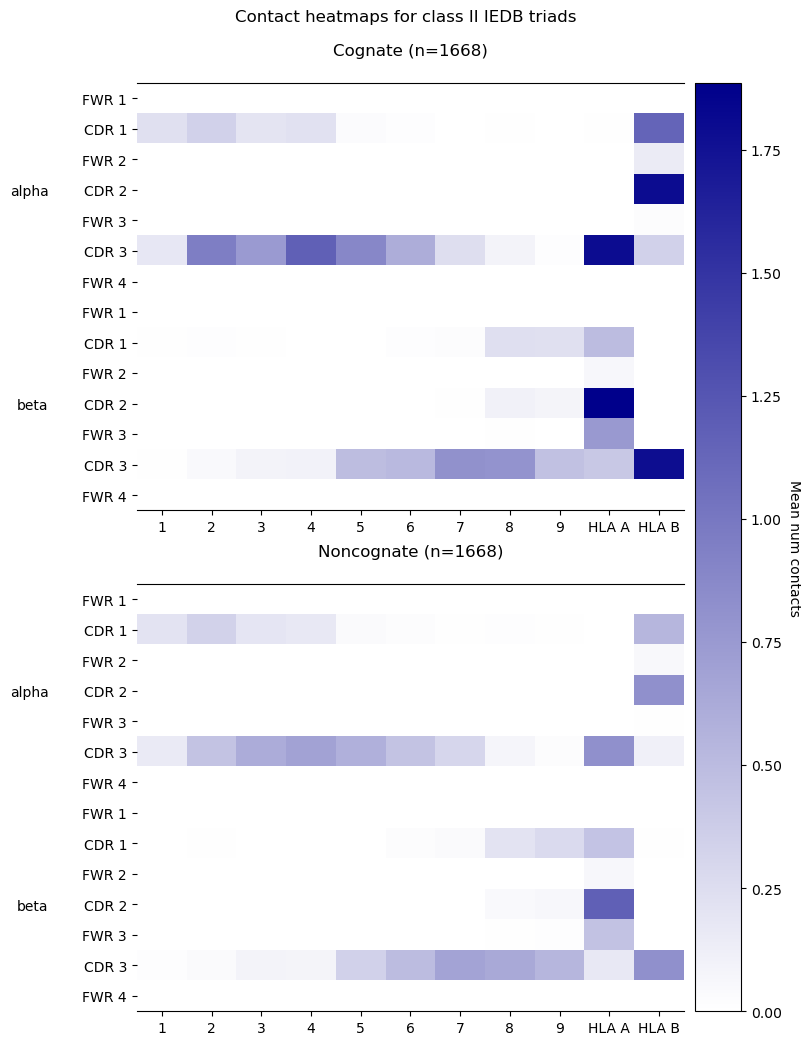

In [44]:
contact_cog, contact_noncog = get_contact_ndarr(
    iedb_II_1x_neg_conf.filter(
        pl.col("peptide").str.len_chars() >= 9,
    )
)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "II",
    suptitle="Contact heatmaps for class II IEDB triads",
)

In [45]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "II")

fold_change = np.log2((cog_exp + 1) / (cog_nonexp + 1))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "II")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([1, 2, 4, 6, 7]) and expected MHC-facing ([0, 3, 5, 8]) positions:
	0.0 
 p value:
	3.085125605902892e-11


## IEDB class I triads


### Length distribution


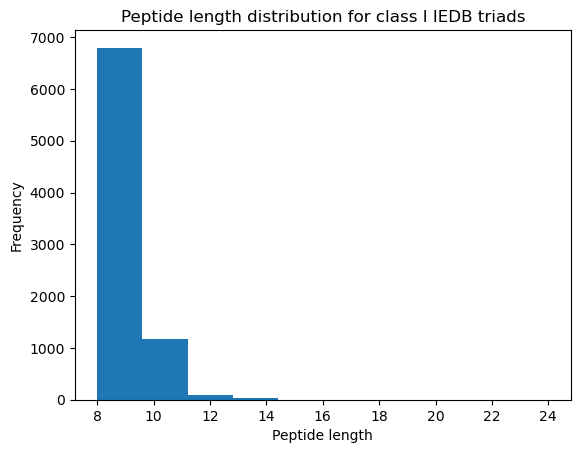

In [46]:
len_dist = iedb_I_1x_neg_conf.filter(
    pl.col("mhc_class") == "I", pl.col("cognate")
).select(pl.col("peptide").str.len_chars())

plot_histogram(len_dist, title="Peptide length distribution for class I IEDB triads")

### Heatmap


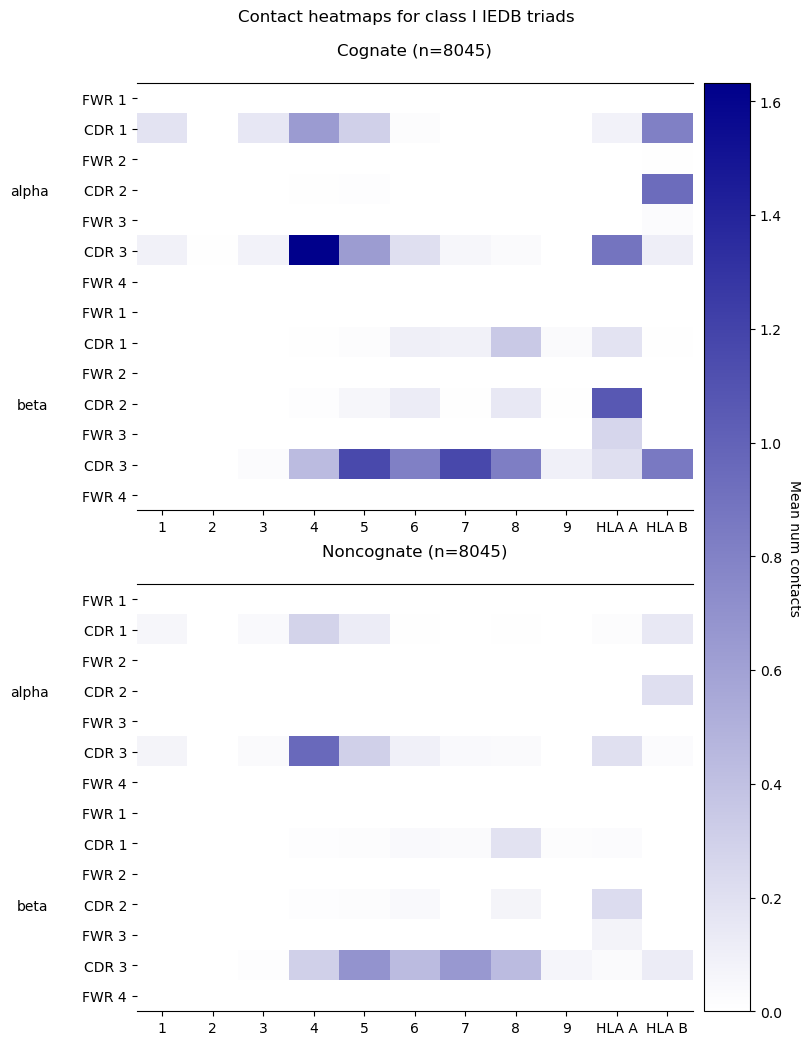

In [47]:
contact_cog, contact_noncog = get_contact_ndarr(
    iedb_I_1x_neg_conf.filter(
        pl.col("peptide").str.len_chars() >= 9,
    )
)

fig = plot_heatmap(
    contact_cog,
    contact_noncog,
    "I",
    suptitle="Contact heatmaps for class I IEDB triads",
)

In [48]:
cog_exp, cog_nonexp = collapse_contact_maps(contact_cog, "I")

fold_change = np.log2((cog_exp + 1) / (cog_nonexp + 1))

_, pval = wilcoxon_exp_vs_nonexp(fold_change, "I")

Median logfold change in mean number of TCR contacts between expected TCR-facing
([3, 4, 5, 6, 7]) and expected MHC-facing ([0, 1, 2, 8]) positions:
	1.1375035237499351 
 p value:
	0.0
